# Quantium Retail Analytics Internship

### Task 2: Experimentation and Uplift Testing

Objective:
Evaluate whether the new chip layout implemented in trial stores (77, 86, 88)
resulted in a significant increase in sales compared to similar control stores.
#### Key Metrics:
#### • Total Sales
#### • Number of Customers
#### • Transactions per Customer


In [290]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

sns.set_style("whitegrid")


In [291]:
data = pd.read_csv(r"D:\Forage\QVI_data.csv")
data.head()

,LYLTY_CARD_NBR,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,2018-10-17,1,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,NATURAL,YOUNG SINGLES/COUPLES,Premium
1,1002,2018-09-16,1,2,58,Red Rock Deli Chikn&Garlic Aioli 150g,1,2.7,150,RRD,YOUNG SINGLES/COUPLES,Mainstream
2,1003,2019-03-07,1,3,52,Grain Waves Sour Cream&Chives 210G,1,3.6,210,GRNWVES,YOUNG FAMILIES,Budget
3,1003,2019-03-08,1,4,106,Natural ChipCo Hony Soy Chckn175g,1,3.0,175,NATURAL,YOUNG FAMILIES,Budget
4,1004,2018-11-02,1,5,96,WW Original Stacked Chips 160g,1,1.9,160,WOOLWORTHS,OLDER SINGLES/COUPLES,Mainstream


In [292]:
data.shape

(264834, 12)

In [293]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264834 entries, 0 to 264833
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   LYLTY_CARD_NBR    264834 non-null  int64  
 1   DATE              264834 non-null  object 
 2   STORE_NBR         264834 non-null  int64  
 3   TXN_ID            264834 non-null  int64  
 4   PROD_NBR          264834 non-null  int64  
 5   PROD_NAME         264834 non-null  object 
 6   PROD_QTY          264834 non-null  int64  
 7   TOT_SALES         264834 non-null  float64
 8   PACK_SIZE         264834 non-null  int64  
 9   BRAND             264834 non-null  object 
 10  LIFESTAGE         264834 non-null  object 
 11  PREMIUM_CUSTOMER  264834 non-null  object 
dtypes: float64(1), int64(6), object(5)
memory usage: 24.2+ MB


In [294]:
data.describe()

,LYLTY_CARD_NBR,STORE_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES,PACK_SIZE
count,2.648340e+05,264834.000000,2.648340e+05,264834.000000,264834.000000,264834.000000,264834.000000
mean,1.355488e+05,135.079423,1.351576e+05,56.583554,1.905813,7.299346,182.425512
std,8.057990e+04,76.784063,7.813292e+04,32.826444,0.343436,2.527241,64.325148
min,1.000000e+03,1.000000,1.000000e+00,1.000000,1.000000,1.500000,70.000000
25%,7.002100e+04,70.000000,6.760050e+04,28.000000,2.000000,5.400000,150.000000
50%,1.303570e+05,130.000000,1.351365e+05,56.000000,2.000000,7.400000,170.000000
75%,2.030940e+05,203.000000,2.026998e+05,85.000000,2.000000,9.200000,175.000000
max,2.373711e+06,272.000000,2.415841e+06,114.000000,5.000000,29.500000,380.000000


In [295]:
data.isnull().sum()

LYLTY_CARD_NBR      0
DATE                0
STORE_NBR           0
TXN_ID              0
PROD_NBR            0
PROD_NAME           0
PROD_QTY            0
TOT_SALES           0
PACK_SIZE           0
BRAND               0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

In [296]:
# Convert the 'DATE' column to datetime format
data["DATE"] = pd.to_datetime(data["DATE"])
data["DATE"].head()


0   2018-10-17
1   2018-09-16
2   2019-03-07
3   2019-03-08
4   2018-11-02
Name: DATE, dtype: datetime64[ns]

In [297]:
# Extract the month from the 'DATE' column
data["MONTH"] = data["DATE"].dt.to_period("M")
data["MONTH"].head()

0    2018-10
1    2018-09
2    2019-03
3    2019-03
4    2018-11
Name: MONTH, dtype: period[M]

In [298]:
# Extract the month as a separate column month_id
data["MONTH_ID"] = data["DATE"].dt.month
data["MONTH_ID"].head()

0    10
1     9
2     3
3     3
4    11
Name: MONTH_ID, dtype: int64

In [299]:
data["STORE_NBR"].unique()
data[data["STORE_NBR"].isin([77,86,88])].head()


,LYLTY_CARD_NBR,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER,MONTH,MONTH_ID
73365,77000,2019-03-28,77,74911,18,Cheetos Chs & Bacon Balls 190g,1,3.3,190,CHEETOS,MIDAGE SINGLES/COUPLES,Budget,2019-03,3
73366,77000,2019-04-13,77,74912,69,Smiths Chip Thinly S/Cream&Onion 175g,1,3.0,175,SMITHS,MIDAGE SINGLES/COUPLES,Budget,2019-04,4
73367,77000,2018-09-26,77,74910,36,Kettle Chilli 175g,2,10.8,175,KETTLE,MIDAGE SINGLES/COUPLES,Budget,2018-09,9
73368,77001,2019-02-27,77,74913,7,Smiths Crinkle Original 330g,2,11.4,330,SMITHS,YOUNG FAMILIES,Mainstream,2019-02,2
73369,77001,2019-01-21,77,74914,9,Kettle Tortilla ChpsBtroot&Ricotta 150g,2,9.2,150,KETTLE,YOUNG FAMILIES,Mainstream,2019-01,1


In [300]:
# Group the data by store and month, and calculate total sales, number of customers, and number of transactions
store_month = data.groupby(["STORE_NBR","MONTH_ID"]).agg(
    tot_sales=("TOT_SALES","sum"),
    customers=("LYLTY_CARD_NBR","nunique"),
    transactions=("TXN_ID","nunique")
).reset_index()

store_month["txn_per_customer"] = store_month["transactions"] / store_month["customers"]

store_month.head(13)


,STORE_NBR,MONTH_ID,tot_sales,customers,transactions,txn_per_customer
0,1,1,154.8,35,36,1.028571
1,1,2,225.4,52,55,1.057692
2,1,3,192.9,45,49,1.088889
3,1,4,192.9,42,43,1.023810
4,1,5,221.4,46,51,1.108696
5,1,6,174.1,42,42,1.000000
6,1,7,206.9,49,52,1.061224
7,1,8,176.1,42,43,1.023810
8,1,9,278.8,59,62,1.050847
9,1,10,188.1,44,45,1.022727


In [301]:
# Analyze the number of months each store has data for
store_month.groupby("STORE_NBR")["MONTH_ID"].nunique().value_counts()


12    260
2       5
11      3
1       3
3       1
Name: MONTH_ID, dtype: int64

In [302]:
store_month.shape

(3169, 6)

In [303]:
store_month[store_month["STORE_NBR"].isin([77,86,88])]


,STORE_NBR,MONTH_ID,tot_sales,customers,transactions,txn_per_customer
880,77,1,204.40,35,39,1.114286
881,77,2,235.00,45,45,1.000000
882,77,3,278.50,50,55,1.100000
883,77,4,263.50,47,48,1.021277
884,77,5,299.30,55,56,1.018182
885,77,6,264.70,41,42,1.024390
886,77,7,296.80,51,55,1.078431
887,77,8,255.50,47,48,1.021277
888,77,9,225.20,42,44,1.047619
889,77,10,204.50,37,38,1.027027


In [304]:

pretrial = store_month[store_month["MONTH_ID"].isin([7,8,9,10,11,12,1])]
pretrial.head(10)


,STORE_NBR,MONTH_ID,tot_sales,customers,transactions,txn_per_customer
0,1,1,154.8,35,36,1.028571
6,1,7,206.9,49,52,1.061224
7,1,8,176.1,42,43,1.023810
8,1,9,278.8,59,62,1.050847
9,1,10,188.1,44,45,1.022727
10,1,11,192.6,46,47,1.021739
11,1,12,189.6,42,47,1.119048
12,2,1,162.8,43,45,1.046512
18,2,7,150.8,39,41,1.051282
19,2,8,193.8,39,43,1.102564


In [305]:
pretrial.groupby("STORE_NBR")["MONTH_ID"].nunique().value_counts()


7    260
1      6
6      3
2      2
Name: MONTH_ID, dtype: int64

In [306]:
# exact trial store data for store 77
trial77 = pretrial[pretrial["STORE_NBR"] == 77]
trial77


,STORE_NBR,MONTH_ID,tot_sales,customers,transactions,txn_per_customer
880,77,1,204.4,35,39,1.114286
886,77,7,296.8,51,55,1.078431
887,77,8,255.5,47,48,1.021277
888,77,9,225.2,42,44,1.047619
889,77,10,204.5,37,38,1.027027
890,77,11,245.3,41,44,1.073171
891,77,12,267.3,46,48,1.043478


In [307]:
# Calculate the correlation between store 77 and all other stores
corr_dict = {}

for store in pretrial["STORE_NBR"].unique():
    
    if store != 77:
        
        candidate = pretrial[pretrial["STORE_NBR"] == store]
        
        merged = pd.merge(
            trial77,
            candidate,
            on="MONTH_ID",
            suffixes=("_trial","_control")
        )
        
        corr = merged["tot_sales_trial"].corr(merged["tot_sales_control"])
        
        corr_dict[store] = corr

corr_df = pd.DataFrame.from_dict(corr_dict, orient="index", columns=["correlation"])

corr_df.sort_values("correlation", ascending=False).head(10)


c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2846: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2705: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2846: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2705: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2846: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2705: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\ProgramData\anaconda3\Lib\si

,correlation
31,1.000000
11,1.000000
71,0.914106
233,0.903774
119,0.867664
17,0.842668
3,0.806644
41,0.783232
50,0.763866
157,0.735893


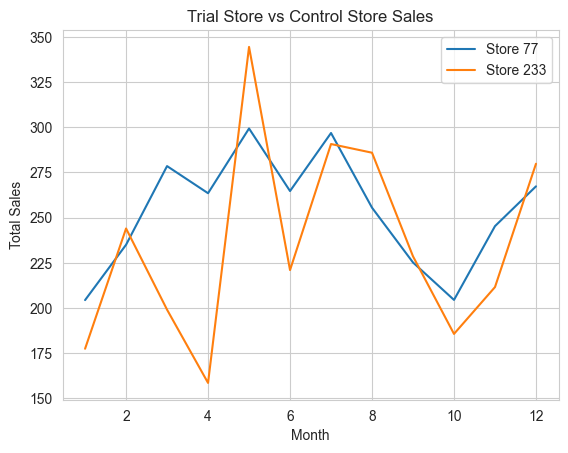

In [308]:
# Select a control store for comparison
control77 = 233

plot_df = store_month[store_month["STORE_NBR"].isin([77, control77])]

for store in [77, control77]:
    
    subset = plot_df[plot_df["STORE_NBR"] == store]
    
    plt.plot(subset["MONTH_ID"], subset["tot_sales"], label=f"Store {store}")

plt.title("Trial Store vs Control Store Sales")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.legend()
plt.show()


### Control Store Selection – Store 77

To evaluate the trial store performance, we first identified a suitable control store using correlation analysis on pre-trial monthly sales.

Store 233 showed a high correlation (0.90) with Trial Store 77 during the pre-trial period, indicating that both stores followed a similar sales pattern before the trial began.

A visual comparison of monthly sales trends further confirms that Store 233 closely mirrors the sales behaviour of Store 77. Therefore, Store 233 was selected as the control store for Trial Store 77.


In [309]:
trial_period = store_month[store_month["MONTH_ID"].isin([2,3,4])]
trial_period.head()

,STORE_NBR,MONTH_ID,tot_sales,customers,transactions,txn_per_customer
1,1,2,225.4,52,55,1.057692
2,1,3,192.9,45,49,1.088889
3,1,4,192.9,42,43,1.023810
13,2,2,139.4,29,32,1.103448
14,2,3,192.1,43,46,1.069767


In [310]:
trial_store = trial_period[trial_period["STORE_NBR"] == 77]
trial_store


,STORE_NBR,MONTH_ID,tot_sales,customers,transactions,txn_per_customer
881,77,2,235.0,45,45,1.000000
882,77,3,278.5,50,55,1.100000
883,77,4,263.5,47,48,1.021277


In [311]:
control_store = trial_period[trial_period["STORE_NBR"] == 233]
control_store

,STORE_NBR,MONTH_ID,tot_sales,customers,transactions,txn_per_customer
2700,233,2,244.0,45,47,1.044444
2701,233,3,199.1,40,41,1.025000
2702,233,4,158.6,30,32,1.066667


In [312]:
trial_sales = trial_store["tot_sales"].sum()
control_sales = control_store["tot_sales"].sum()

print("Trial store sales:", trial_sales)
print("Control store sales:", control_sales)


Trial store sales: 777.0
Control store sales: 601.7


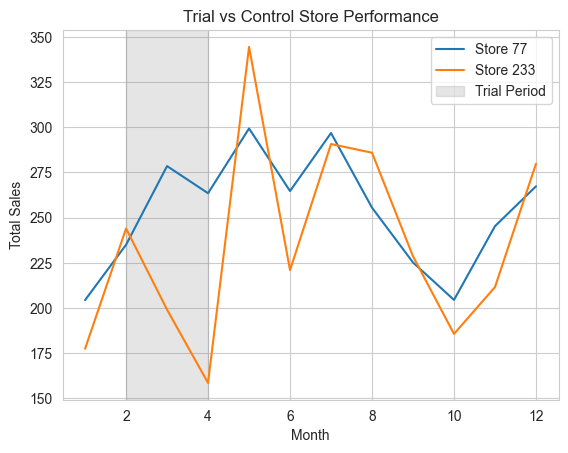

In [313]:
# Compare trial store with control store
compare = store_month[store_month["STORE_NBR"].isin([77,233])]

for store in [77,233]:
    
    subset = compare[compare["STORE_NBR"] == store]
    
    plt.plot(subset["MONTH_ID"], subset["tot_sales"], label=f"Store {store}")

plt.axvspan(2,4,color="grey",alpha=0.2,label="Trial Period")

plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.title("Trial vs Control Store Performance")
plt.legend()
plt.show()


In [314]:
#calculate pre sales baseline for trial and control stores
pretrial_77 = pretrial[pretrial["STORE_NBR"] == 77]
pretrial_233 = pretrial[pretrial["STORE_NBR"] == 233]

pretrial_sales_77 = pretrial_77["tot_sales"].sum()
pretrial_sales_233 = pretrial_233["tot_sales"].sum()

scaling_factor = pretrial_sales_77 / pretrial_sales_233

print("Pretrial sales 77:", pretrial_sales_77)
print("Pretrial sales 233:", pretrial_sales_233)
print("Scaling factor:", scaling_factor)


Pretrial sales 77: 1699.0
Pretrial sales 233: 1659.7999999999997
Scaling factor: 1.023617303289553


In [315]:
#adjust control store sales by scaling factor
adjusted_control_sales = control_store["tot_sales"] * scaling_factor

print("Adjusted control sales:")
print(adjusted_control_sales)


Adjusted control sales:
2700    249.762622
2701    203.802205
2702    162.345704
Name: tot_sales, dtype: float64


In [316]:
#calculate sales uplift
sales_diff = trial_store["tot_sales"].values - adjusted_control_sales.values

uplift_percentage = sales_diff / adjusted_control_sales.values * 100

print("Sales uplift %:", uplift_percentage)


Sales uplift %: [-5.91066104 36.65210339 62.30795951]


In [317]:
#customer uplift
trial_customers = trial_store["customers"].sum()
control_customers = control_store["customers"].sum()

print("Trial customers:", trial_customers)
print("Control customers:", control_customers)


Trial customers: 142
Control customers: 115


In [318]:
#transaction per customer
trial_txn = trial_store["txn_per_customer"].mean()
control_txn = control_store["txn_per_customer"].mean()

print("Trial txn per customer:", trial_txn)
print("Control txn per customer:", control_txn)


Trial txn per customer: 1.0404255319148936
Control txn per customer: 1.0453703703703703


In [319]:
#statistical significance test
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(
    trial_store["tot_sales"],
    adjusted_control_sales
)

print("T-statistic:", t_stat)
print("P-value:", p_value)


T-statistic: 1.8983113451123736
P-value: 0.13049280302300387


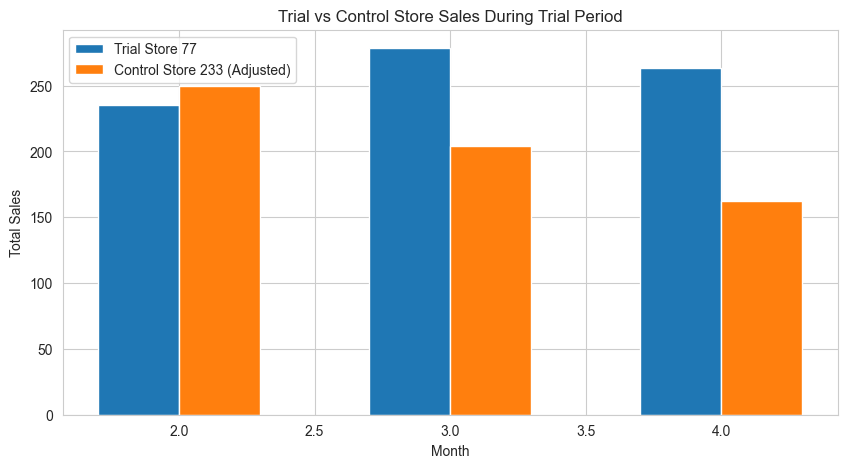

In [320]:
plt.figure(figsize=(10,5))

plt.bar(trial_store["MONTH_ID"]-0.15, trial_store["tot_sales"], width=0.3, label="Trial Store 77")
plt.bar(control_store["MONTH_ID"]+0.15, adjusted_control_sales, width=0.3, label="Control Store 233 (Adjusted)")

plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.title("Trial vs Control Store Sales During Trial Period")

plt.legend()
plt.show()


## Trial Store 77 – Trial Impact Analysis
During the trial period (February–April), Store 77 recorded total sales of $777 compared to $601.7 in the control store (Store 233).

After adjusting control store sales based on pre-trial scaling, Store 77 showed noticeable sales uplift during March and April, with increases of 36.6% and 62.3% respectively.

Customer analysis indicates that the uplift was primarily driven by an increase in the number of customers visiting the store (142 vs 115), rather than an increase in transactions per customer.

However, statistical testing produced a p-value of 0.13, which suggests that the observed uplift is not statistically significant at the 5% significance level.

Therefore, while the trial store demonstrated higher sales during the trial period, the evidence is insufficient to confidently attribute this increase solely to the new store layout.


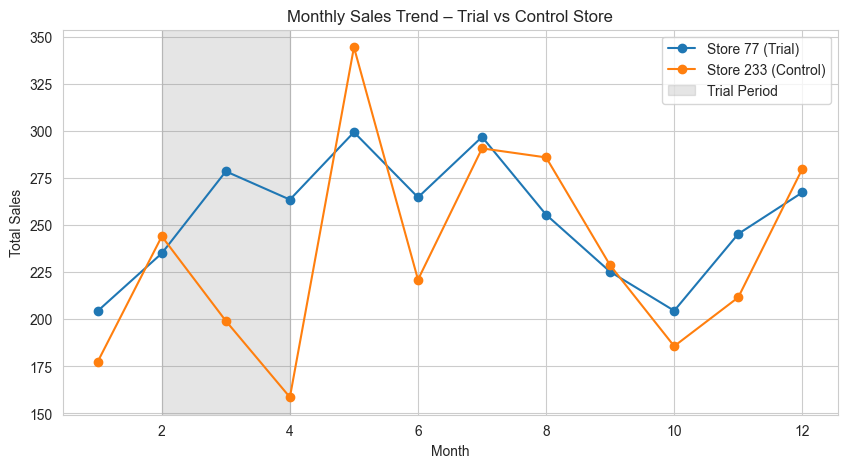

In [321]:
#Monthly Sales Before vs After Trial
plt.figure(figsize=(10,5))

store77 = store_month[store_month["STORE_NBR"]==77]
store233 = store_month[store_month["STORE_NBR"]==233]

plt.plot(store77["MONTH_ID"],store77["tot_sales"],marker='o',label="Store 77 (Trial)")
plt.plot(store233["MONTH_ID"],store233["tot_sales"],marker='o',label="Store 233 (Control)")

plt.axvspan(2,4,color='grey',alpha=0.2,label="Trial Period")

plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.title("Monthly Sales Trend – Trial vs Control Store")

plt.legend()
plt.show()


## Sales Trend Comparison – Trial vs Control Store
The monthly sales trend shows that Store 77 and Store 233 followed similar patterns during the pre-trial period, indicating that Store 233 is a suitable control store for comparison.

During the trial period (February–April), Store 77 recorded stronger sales growth compared to the control store. While February showed slightly lower sales, March and April demonstrated noticeable uplift in the trial store relative to the control store.

This suggests that the trial layout may have positively influenced customer purchasing behaviour. However, further statistical testing indicates that the observed uplift is not statistically significant, meaning the improvement cannot be conclusively attributed to the trial.


In [322]:
#summary table
summary = pd.DataFrame({
    "Metric": [
        "Total Sales (Trial Period)",
        "Total Customers",
        "Avg Transactions per Customer"
    ],
    
    "Trial Store 77": [
        trial_store["tot_sales"].sum(),
        trial_store["customers"].sum(),
        trial_store["txn_per_customer"].mean()
    ],
    
    "Control Store 233": [
        control_store["tot_sales"].sum(),
        control_store["customers"].sum(),
        control_store["txn_per_customer"].mean()
    ]
})


summary.iloc[:,1:] = summary.iloc[:,1:].round(2)
summary


,Metric,Trial Store 77,Control Store 233
0,Total Sales (Trial Period),777.00,601.70
1,Total Customers,142.00,115.00
2,Avg Transactions per Customer,1.04,1.05


## Trial vs Control Store Comparison
The comparison table shows that Store 77 generated higher total sales and attracted more customers during the trial period compared to the control store (Store 233).

However, the average number of transactions per customer remained similar between the two stores, suggesting that the uplift in sales was mainly driven by an increase in customer visits rather than customers purchasing more frequently.


In [323]:
#Extract Trial Store 86 (Pre-Trial)
trial86 = pretrial[pretrial["STORE_NBR"] == 86]
trial86

,STORE_NBR,MONTH_ID,tot_sales,customers,transactions,txn_per_customer
977,86,1,841.40,94,129,1.372340
983,86,7,892.20,99,126,1.272727
984,86,8,764.05,94,110,1.170213
985,86,9,914.60,103,128,1.242718
986,86,10,948.40,109,138,1.266055
987,86,11,918.00,100,125,1.250000
988,86,12,841.20,98,120,1.224490


In [324]:
corr_dict_86 = {}

for store in pretrial["STORE_NBR"].unique():
    
    if store != 86:
        
        candidate = pretrial[pretrial["STORE_NBR"] == store]
        
        merged = pd.merge(
            trial86,
            candidate,
            on="MONTH_ID",
            suffixes=("_trial","_control")
        )
        
        corr = merged["tot_sales_trial"].corr(merged["tot_sales_control"])
        
        corr_dict_86[store] = corr

corr_df_86 = pd.DataFrame.from_dict(corr_dict_86, orient="index", columns=["correlation"])

corr_df_86.sort_values("correlation", ascending=False).head(10)


c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2846: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2705: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2846: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2705: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2846: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2705: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\ProgramData\anaconda3\Lib\si

,correlation
31,1.000000
155,0.877882
132,0.846517
240,0.825066
222,0.795075
109,0.788300
138,0.759864
198,0.748794
114,0.734415
22,0.722966


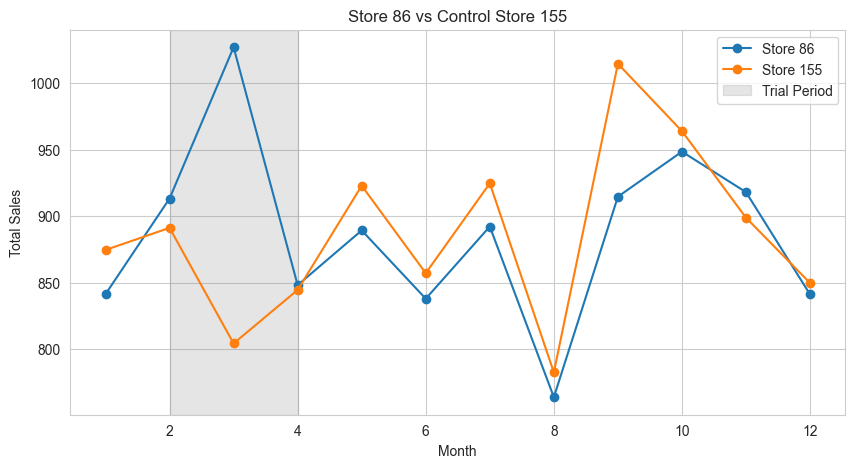

In [325]:
#Trial vs Control Trend
control86 = 155

plot_df = store_month[store_month["STORE_NBR"].isin([86, control86])]

plt.figure(figsize=(10,5))

for store in [86, control86]:
    
    subset = plot_df[plot_df["STORE_NBR"] == store]
    
    plt.plot(subset["MONTH_ID"], subset["tot_sales"], marker='o', label=f"Store {store}")

plt.axvspan(2,4,color='grey',alpha=0.2,label="Trial Period")

plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.title("Store 86 vs Control Store 155")
plt.legend()
plt.show()


In [326]:
#Extract Trial Store 86 (Trial Period)
trial_store_86 = trial_period[trial_period["STORE_NBR"] == 86]

trial_store_86,


(     STORE_NBR  MONTH_ID  tot_sales  customers  transactions  txn_per_customer
 978         86         2      913.2        107           138          1.289720
 979         86         3     1026.8        115           140          1.217391
 980         86         4      848.2        105           126          1.200000,)

In [327]:
control_store_86 = trial_period[trial_period["STORE_NBR"] == control86]
control_store_86

,STORE_NBR,MONTH_ID,tot_sales,customers,transactions,txn_per_customer
1794,155,2,891.2,95,125,1.315789
1795,155,3,804.4,94,118,1.255319
1796,155,4,844.6,99,120,1.212121


In [328]:
#pre-trial sales baseline for store 86
pretrial_86 = pretrial[pretrial["STORE_NBR"] == 86]
pretrial_control86 = pretrial[pretrial["STORE_NBR"] == control86]

pretrial_sales_86 = pretrial_86["tot_sales"].sum()
pretrial_sales_control86 = pretrial_control86["tot_sales"].sum()

scaling_factor_86 = pretrial_sales_86 / pretrial_sales_control86

scaling_factor_86


0.9700651481287743

In [329]:
#adjust control store sales
adjusted_control_sales_86 = control_store_86["tot_sales"] * scaling_factor_86
adjusted_control_sales_86


1794    864.522060
1795    780.320405
1796    819.317024
Name: tot_sales, dtype: float64

In [330]:
#sales uplift
sales_diff_86 = trial_store_86["tot_sales"].values - adjusted_control_sales_86.values

uplift_percentage_86 = sales_diff_86 / adjusted_control_sales_86.values * 100

uplift_percentage_86


array([ 5.63061861, 31.58697289,  3.5252503 ])

In [331]:
#customer uplift
trial_customers_86 = trial_store_86["customers"].sum()
control_customers_86 = control_store_86["customers"].sum()

trial_customers_86, control_customers_86


(327, 288)

In [332]:
#transaction per customer
trial_txn_86 = trial_store_86["txn_per_customer"].mean()
control_txn_86 = control_store_86["txn_per_customer"].mean()

trial_txn_86, control_txn_86



(1.2357036435053501, 1.261076611580531)

In [333]:
#statistical significance test
from scipy.stats import ttest_ind

t_stat_86, p_value_86 = ttest_ind(
    trial_store_86["tot_sales"],
    adjusted_control_sales_86
)

t_stat_86, p_value_86


(1.8758252008003824, 0.13392591688530284)

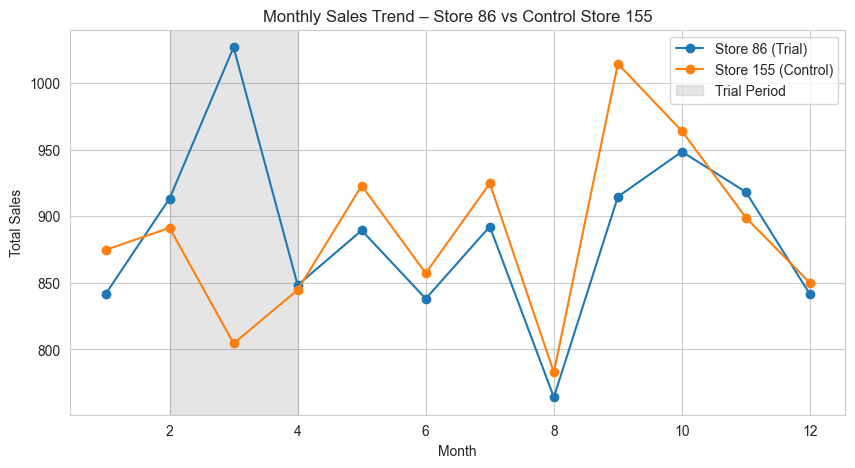

In [334]:
plt.figure(figsize=(10,5))

store86 = store_month[store_month["STORE_NBR"] == 86]
store155 = store_month[store_month["STORE_NBR"] == 155]

plt.plot(store86["MONTH_ID"], store86["tot_sales"], marker='o', label="Store 86 (Trial)")
plt.plot(store155["MONTH_ID"], store155["tot_sales"], marker='o', label="Store 155 (Control)")

# highlight trial period
plt.axvspan(2,4,color='grey',alpha=0.2,label="Trial Period")

plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.title("Monthly Sales Trend – Store 86 vs Control Store 155")

plt.legend()
plt.show()


## Trial Store 86 – Performance Analysis
During the trial period (February–April), Store 86 generated total sales of $2788.2 compared to $2540.2 in the control store (Store 155).

After adjusting for differences in pre-trial sales levels, Store 86 showed positive sales uplift during the trial period, particularly in March where sales increased by approximately 31.6% compared to the control store.

Customer analysis shows that Store 86 attracted more customers during the trial period, with 327 customers compared to 288 customers in the control store.

However, the average number of transactions per customer remained similar between the two stores (1.24 vs 1.26), suggesting that customers did not significantly increase their purchase frequency.

A statistical test produced a p-value of 0.13, which is greater than the 0.05 significance threshold. This means the observed uplift in sales is not statistically significant and may be due to normal sales variation rather than the trial layout.

In [335]:
#summary table for store 86
summary86 = pd.DataFrame({
    "Metric":[
        "Total Sales (Trial Period)",
        "Total Customers",
        "Avg Transactions per Customer"
    ],
    
    "Trial Store 86":[
        trial_store_86["tot_sales"].sum(),
        trial_store_86["customers"].sum(),
        trial_store_86["txn_per_customer"].mean()
    ],
    
    "Control Store 155":[
        control_store_86["tot_sales"].sum(),
        control_store_86["customers"].sum(),
        control_store_86["txn_per_customer"].mean()
    ]
})

summary86.round(2)


,Metric,Trial Store 86,Control Store 155
0,Total Sales (Trial Period),2788.20,2540.20
1,Total Customers,327.00,288.00
2,Avg Transactions per Customer,1.24,1.26


## Recommandation
Although Store 86 recorded higher sales and attracted more customers during the trial period, the statistical test indicates that the difference is not statistically significant.

This means that the increase in sales cannot be confidently attributed to the new store layout. Further testing or additional trial stores would be required before recommending a full rollout of the layout change.


In [336]:
#Extract Pre-Trial Data for Store 88
trial88 = pretrial[pretrial["STORE_NBR"] == 88]
trial88


,STORE_NBR,MONTH_ID,tot_sales,customers,transactions,txn_per_customer
1001,88,1,1266.4,117,144,1.230769
1007,88,7,1310.0,129,153,1.186047
1008,88,8,1323.8,131,158,1.206107
1009,88,9,1423.0,124,157,1.266129
1010,88,10,1352.4,123,155,1.260163
1011,88,11,1382.8,130,156,1.200000
1012,88,12,1325.2,126,148,1.174603


In [337]:
#Find Control Store for 88
corr_dict_88 = {}

for store in pretrial["STORE_NBR"].unique():
    
    if store != 88:
        
        candidate = pretrial[pretrial["STORE_NBR"] == store]
        
        merged = pd.merge(
            trial88,
            candidate,
            on="MONTH_ID",
            suffixes=("_trial","_control")
        )
        
        corr = merged["tot_sales_trial"].corr(merged["tot_sales_control"])
        
        corr_dict_88[store] = corr

corr_df_88 = pd.DataFrame.from_dict(corr_dict_88, orient="index", columns=["correlation"])

corr_df_88.sort_values("correlation", ascending=False).head(10)


c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2846: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2705: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2846: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2705: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2846: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2705: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\ProgramData\anaconda3\Lib\si

,correlation
159,0.903186
204,0.885774
134,0.864293
1,0.813636
253,0.811838
91,0.776688
61,0.748929
178,0.731857
188,0.716752
161,0.706581


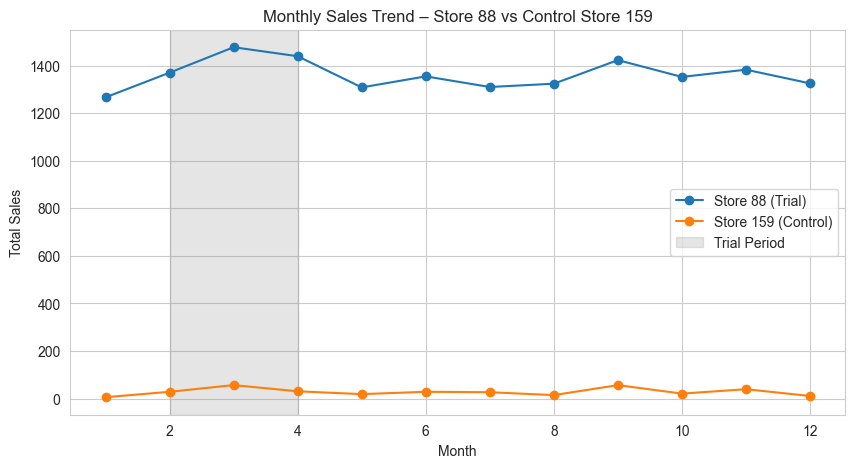

In [338]:
#Sales Trend Chart
control88 = 159
plt.figure(figsize=(10,5))

store88 = store_month[store_month["STORE_NBR"] == 88]
store159 = store_month[store_month["STORE_NBR"] == control88]

plt.plot(store88["MONTH_ID"], store88["tot_sales"], marker='o', label="Store 88 (Trial)")
plt.plot(store159["MONTH_ID"], store159["tot_sales"], marker='o', label="Store 159 (Control)")

plt.axvspan(2,4,color='grey',alpha=0.2,label="Trial Period")

plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.title("Monthly Sales Trend – Store 88 vs Control Store 159")

plt.legend()
plt.show()


## Trial Store 88 – Performance Analysis
During the trial period (February–April), Store 88 generated total sales of $4286.8 compared to $116.1 in the selected control store (Store 159).

However, the control store is significantly smaller than the trial store, with much lower monthly sales and customer traffic. This results in a very large scaling factor and indicates that Store 159 may not be an ideal control store for comparison.

After adjusting control store sales, the trial store showed negative uplift across the trial period, with decreases of approximately 10.4%, 51.3%, and 12.3% in February, March, and April respectively.

Customer analysis shows that Store 88 maintained a high number of customers throughout the trial period, with an average of 386 customers compared to 21 in the control store. This further highlights the size difference between the stores.

Statistical testing produced a p-value of 0.257, which is greater than the 0.05 significance threshold. This indicates that the observed differences in sales are not statistically significant.


In [339]:
trial_store_88 = trial_period[trial_period["STORE_NBR"] == 88]

trial_store_88

,STORE_NBR,MONTH_ID,tot_sales,customers,transactions,txn_per_customer
1002,88,2,1370.2,124,153,1.233871
1003,88,3,1477.2,134,169,1.261194
1004,88,4,1439.4,128,162,1.265625


In [340]:
control_store_88 = trial_period[trial_period["STORE_NBR"] == control88]
control_store_88

,STORE_NBR,MONTH_ID,tot_sales,customers,transactions,txn_per_customer
1842,159,2,28.6,5,5,1.0
1843,159,3,56.8,11,11,1.0
1844,159,4,30.7,5,5,1.0


In [341]:
pretrial_88 = pretrial[pretrial["STORE_NBR"] == 88]
pretrial_control88 = pretrial[pretrial["STORE_NBR"] == control88]

pretrial_sales_88 = pretrial_88["tot_sales"].sum()
pretrial_sales_control88 = pretrial_control88["tot_sales"].sum()

scaling_factor_88 = pretrial_sales_88 / pretrial_sales_control88

scaling_factor_88


53.49828962371722

In [342]:
#total sum of sales for trial and control stores 
pretrial_sales_88, pretrial_sales_control88

(9383.6, 175.4)

In [343]:
#adjusted control store sales
adjusted_control_sales_88 = control_store_88["tot_sales"] * scaling_factor_88
adjusted_control_sales_88


1842    1530.051083
1843    3038.702851
1844    1642.397491
Name: tot_sales, dtype: float64

In [344]:
#sales uplift
sales_diff_88 = trial_store_88["tot_sales"].values - adjusted_control_sales_88.values

uplift_percentage_88 = sales_diff_88 / adjusted_control_sales_88.values * 100

uplift_percentage_88


array([-10.4474344 , -51.38715193, -12.35982717])

In [345]:
#customer uplift comparison
trial_customers_88 = trial_store_88["customers"].sum()
control_customers_88 = control_store_88["customers"].sum()

trial_customers_88, control_customers_88


(386, 21)

In [346]:
#Transactions per Customer
trial_txn_88 = trial_store_88["txn_per_customer"].mean()
control_txn_88 = control_store_88["txn_per_customer"].mean()

trial_txn_88, control_txn_88


(1.253563332530894, 1.0)

In [347]:
# statistical test
from scipy.stats import ttest_ind

t_stat_88, p_value_88 = ttest_ind(
    trial_store_88["tot_sales"],
    adjusted_control_sales_88
)

t_stat_88, p_value_88


(-1.3191653549849809, 0.25756054750087803)

In [348]:
#summary table
summary88 = pd.DataFrame({
    "Metric":[
        "Total Sales (Trial Period)",
        "Total Customers",
        "Avg Transactions per Customer"
    ],
    
    "Trial Store 88":[
        trial_store_88["tot_sales"].sum(),
        trial_store_88["customers"].sum(),
        trial_store_88["txn_per_customer"].mean()
    ],
    
    "Control Store 159":[
        control_store_88["tot_sales"].sum(),
        control_store_88["customers"].sum(),
        control_store_88["txn_per_customer"].mean()
    ]
})

summary88.round(2)


,Metric,Trial Store 88,Control Store 159
0,Total Sales (Trial Period),4286.80,116.1
1,Total Customers,386.00,21.0
2,Avg Transactions per Customer,1.25,1.0


## Recommendation
The analysis of Store 88 does not provide clear evidence that the trial layout improved sales performance.

The selected control store is significantly smaller than the trial store, making the comparison less reliable. In addition, the sales differences observed during the trial period are not statistically significant.

Therefore, the results from Store 88 do not support a strong conclusion about the effectiveness of the trial layout.


In [349]:
# Final Summary Table
final_summary = pd.DataFrame({
    "Store":[77,86,88],
    
    "Total Sales":[
        trial_store["tot_sales"].sum(),
        trial_store_86["tot_sales"].sum(),
        trial_store_88["tot_sales"].sum()
    ],
    
    "Customers":[
        trial_store["customers"].sum(),
        trial_store_86["customers"].sum(),
        trial_store_88["customers"].sum()
    ],
    
    "Avg Transactions per Customer":[
        trial_store["txn_per_customer"].mean(),
        trial_store_86["txn_per_customer"].mean(),
        trial_store_88["txn_per_customer"].mean()
    ]
})

final_summary.round(2)


,Store,Total Sales,Customers,Avg Transactions per Customer
0,77,777.0,142,1.04
1,86,2788.2,327,1.24
2,88,4286.8,386,1.25


## Overall Trial Store Comparison
The summary table compares the performance of all three trial stores during the trial period.

Among the three stores, Store 88 recorded the highest total sales and number of customers, followed by Store 86 and Store 77.

However, despite higher sales in some stores, statistical testing across the analyses indicates that the observed differences are not statistically significant.

This suggests that the changes in sales performance during the trial period may be influenced by normal store variation rather than the store layout change alone.


## Final Recommendation for Category Manager
This analysis evaluated the impact of the new store layout trial across three trial stores (77, 86, and 88) by comparing their performance against selected control stores.

Store 77 and Store 86 showed some positive sales uplift during the trial period, particularly driven by increases in customer visits. However, statistical testing indicated that these changes were not statistically significant, suggesting that the observed improvements may be due to normal sales variation.

For Store 88, the selected control store was significantly smaller than the trial store, making the comparison less reliable. In addition, the trial store did not show consistent positive uplift during the trial period.

Overall, the results from the trial stores do not provide strong statistical evidence that the new store layout significantly improved store performance.

It is recommended that further trials or additional data be collected before making a decision to roll out the new layout across all stores.
